# Multilevel Regression Testing `City_Category` as Group

This notebook tests mixed-effects regression using `City_Category` as the grouping variable:

`performance_score ~ selected urban-form predictors + (1 | City_Category)`

Important statistical caveat: there are only five city-size categories. Random effects are usually unstable with so few groups. Treat this notebook as a sensitivity test, not the main model. The notebook also fits OLS alternatives for comparison.

In [1]:
# ========================= Imports and Settings =========================
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.options.display.float_format = "{:.4f}".format
sns.set_theme(style="whitegrid")

OUT_DIR = "../output/multilevel_regression_city_category_group"
os.makedirs(OUT_DIR, exist_ok=True)

VIF_THRESHOLD = 5.0
CORR_THRESHOLD = 0.90

## 1. Load Data and Define Variables

In [2]:
DATA_PATH = "../data/grid500_performance_score.csv"
grid500 = pd.read_csv(DATA_PATH, index_col=0)

target = "performance_score"
group_col = "City_Category"

features = [
    'buildingCount', 'totalHeight', 'avgHeight', 'basePerimeterTotal',
    'basePerimeterAvg', 'compactness', 'footprintAreaTotal', 'totalArea',
    'avgBuildingArea', 'FAR', 'coverageRatio',
    'roadDensity', 'intersectionDensity', 'poiDensity', 'poiDiversity',
    'FVC', 'permeableRatio', 'maxHeight', 'minHeight', 'heightRange', 'heightIndex',
    'heightDensity', 'heightOtherness', 'cornerCountTotal', 'basePerimeterMax',
    'basePerimeterMin', 'shapeComplexity', 'areaVariance', 'parcelArea',
    'largestPatchIndex', 'shape3DIndex', 'evennessIndex', 'cornerCountAvg',
    'buildingProximity', 'buildingMinDist', 'buildingMaxDist',
    'buildingDistAvg', 'buildingDistVar', 'SVF', 'streetRatio'
]

print(grid500.shape)
grid500.head()

(194941, 51)


,Global_ID,City,NTL2023,NTL2023_focal,VIT202311,UHIDAY2020_07_inv,buildingCount,totalHeight,avgHeight,maxHeight,minHeight,heightRange,heightIndex,heightDensity,heightOtherness,cornerCountTotal,basePerimeterTotal,basePerimeterAvg,basePerimeterMax,basePerimeterMin,shapeComplexity,compactness,footprintAreaTotal,totalArea,areaVariance,avgBuildingArea,parcelArea,largestPatchIndex,shape3DIndex,SVF,evennessIndex,FAR,coverageRatio,FVC,permeableRatio,poiDensity,poiDiversity,streetRatio,roadDensity,intersectionDensity,cornerCountAvg,buildingProximity,buildingMinDist,buildingMaxDist,buildingDistAvg,buildingDistVar,cluster_label,log_NTL2023_focal,log_VIT202311,distance_to_surface,performance_score
0,0,Beijing,6.1850,7.0300,1649.8571,0.4728,31,93.0000,3.0000,3.0000,3.0000,0.0000,0.0323,0.0004,0.0000,180,6500.9830,209.7091,831.6324,32.5533,5.0701,0.5614,88704.5751,88704.5751,50961857.7000,2861.4379,132998.2511,0.4670,0.0082,0.8024,234.6035,0.3548,0.3548,0.8366,0.8948,4.0000,0.0000,0.1994,5,1,5.8065,52.5611,14.9887,620.9377,268.0891,2565.5688,5.0000,0.3557,0.6654,0.2119,0.7542
1,1,Beijing,5.7400,7.2261,155.8571,0.4728,29,87.0000,3.0000,3.0000,3.0000,0.0000,0.0345,0.0003,0.0000,149,3810.3930,131.3929,272.1380,15.3292,5.1700,0.6206,33119.4905,33119.4905,1261729.8840,1142.0514,196625.2176,0.6683,0.2644,0.8906,35.6626,0.1325,0.1325,0.8570,0.9383,12.0000,0.6365,0.1994,7,1,5.1379,34.2211,6.8159,594.1575,300.0878,2010.8442,5.0000,0.3598,0.4540,0.3538,0.5893
2,2,Beijing,11.3200,13.6167,57.1429,0.4728,22,66.0000,3.0000,3.0000,3.0000,0.0000,0.0455,0.0003,0.0000,117,3645.3976,165.6999,668.2643,28.7300,4.9243,0.5589,51092.8628,51092.8628,30358745.8300,2322.4029,132197.3125,0.5288,0.0134,0.8982,151.4966,0.2044,0.2044,0.8818,0.9257,0.0000,0.0000,0.1994,1,0,5.3182,47.9015,17.3445,610.8432,283.8433,2044.7287,5.0000,0.4580,0.3649,0.4015,0.5339
3,3,Beijing,11.7300,14.3617,243.5714,0.4728,8,24.0000,3.0000,3.0000,3.0000,0.0000,0.1250,0.0001,0.0000,42,1147.5982,143.4498,283.0113,75.6611,5.7024,0.5969,8534.6141,8534.6141,958399.8878,1066.8268,205685.3683,0.8227,0.0179,0.9475,15.5408,0.0341,0.0341,0.9335,0.9785,0.0000,0.0000,0.1994,3,1,5.2500,35.9269,13.4894,474.1686,232.3126,1896.1434,5.0000,0.4665,0.4939,0.3050,0.6460
4,4,Beijing,8.4500,9.1900,0.0000,0.4728,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,99.1487,0.0004,0.0000,0.9777,0.0000,0.0000,0.0000,0.8153,0.9844,16.0000,0.6931,0.0000,1,1,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.3964,0.0000,0.6089,0.2930


## 2. Create `City_Category`

In [3]:
city_categories = {
    'Super Large-Sized City': ['Beijing', 'Tianjin', 'Shanghai', 'Guangzhou', 'Shenzhen', 'Chongqing', 'Chengdu'],
    'Very Large-Sized City': ['Shenyang', 'Harbin', 'Nanjing', 'Hangzhou', 'Jinan', 'Zhengzhou', 'Wuhan', 'Changsha', 'Kunming', 'Xian', 'Dalian', 'Qingdao'],
    'Type I Large-Sized City': ['Shijiazhuang', 'Taiyuan', 'Changchun', 'Hefei', 'Fuzhou', 'Nanchang', 'Nanning', 'Guiyang', 'Urumqi', 'Ningbo', 'Xiamen'],
    'Type II Large-Sized City': ['Hohhot', 'Haikou', 'Lanzhou', 'Xining', 'Yinchuan'],
    'Medium-Sized City': ['Lasa']
}

city_to_category = {
    city: category
    for category, city_list in city_categories.items()
    for city in city_list
}

category_order = list(city_categories.keys())
grid500['City_Category'] = grid500['City'].map(city_to_category)
grid500['City_Category'] = pd.Categorical(
    grid500['City_Category'],
    categories=category_order,
    ordered=True
)

display(grid500[['City', 'City_Category']].drop_duplicates().sort_values(['City_Category', 'City']))
display(grid500['City_Category'].value_counts(dropna=False))

,City,City_Category
0,Beijing,Super Large-Sized City
23833,Chengdu,Super Large-Sized City
31403,Chongqing,Super Large-Sized City
45986,Guangzhou,Super Large-Sized City
119043,Shanghai,Super Large-Sized City
141054,Shenzhen,Super Large-Sized City
153106,Tianjin,Super Large-Sized City
20509,Changsha,Very Large-Sized City
37901,Dalian,Very Large-Sized City
59711,Hangzhou,Very Large-Sized City


City_Category
Very Large-Sized City       73559
Super Large-Sized City      71818
Type I Large-Sized City     38366
Type II Large-Sized City    10173
Medium-Sized City            1025
Name: count, dtype: int64

## 3. Clean Modeling Data

In [4]:
required_cols = [target, group_col] + features
missing_cols = [c for c in required_cols if c not in grid500.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

df = (
    grid500[required_cols]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .copy()
)

df[group_col] = pd.Categorical(df[group_col], categories=category_order, ordered=True)

print("Rows after cleaning:", len(df))
print("Groups:", df[group_col].nunique())
display(df.groupby(group_col)[target].agg(['count', 'mean', 'std', 'min', 'max']))

Rows after cleaning: 194941
Groups: 5


,count,mean,std,min,max
City_Category,,,,,
Super Large-Sized City,71818,0.6557,0.1260,0.0000,0.9989
Very Large-Sized City,73559,0.6543,0.1403,0.0125,1.0000
Type I Large-Sized City,38366,0.6750,0.1438,0.0710,0.9998
Type II Large-Sized City,10173,0.6656,0.1556,0.0421,0.9992
Medium-Sized City,1025,0.6228,0.1657,0.1403,0.9362


## 4. Feature Screening With Strict VIF

In [5]:
def correlation_prune(data, cols, threshold=0.90):
    corr = data[cols].corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    drop_cols = [col for col in upper.columns if any(upper[col] > threshold)]
    keep_cols = [col for col in cols if col not in drop_cols]
    return keep_cols, drop_cols, corr


def calculate_vif_table(data, cols):
    X = data[cols].astype(float).copy()
    X = pd.DataFrame(StandardScaler().fit_transform(X), columns=cols, index=X.index)
    X = sm.add_constant(X)

    rows = []
    for i, col in enumerate(X.columns):
        if col == 'const':
            continue
        rows.append({'feature': col, 'VIF': variance_inflation_factor(X.values, i)})
    return pd.DataFrame(rows).sort_values('VIF', ascending=False)


def vif_prune(data, cols, threshold=5.0, min_features=5):
    keep = list(cols)
    dropped = []

    while len(keep) > min_features:
        vif_table = calculate_vif_table(data, keep)
        max_vif = vif_table['VIF'].max()
        if max_vif <= threshold:
            break

        worst_feature = vif_table.iloc[0]['feature']
        dropped.append((worst_feature, max_vif))
        keep.remove(worst_feature)

    return keep, pd.DataFrame(dropped, columns=['feature', 'VIF_when_dropped'])


corr_keep, corr_dropped, corr_matrix = correlation_prune(df, features, threshold=CORR_THRESHOLD)
selected_features, vif_dropped = vif_prune(df, corr_keep, threshold=VIF_THRESHOLD, min_features=8)
final_vif = calculate_vif_table(df, selected_features)

print("Original feature count:", len(features))
print("Dropped by correlation:", len(corr_dropped))
print("Dropped by VIF:", len(vif_dropped))
print("Selected feature count:", len(selected_features))
print(selected_features)

pd.Series(corr_dropped, name='dropped_by_correlation').to_csv(f'{OUT_DIR}/dropped_by_correlation.csv', index=False)
vif_dropped.to_csv(f'{OUT_DIR}/dropped_by_vif.csv', index=False)
final_vif.to_csv(f'{OUT_DIR}/final_vif_table.csv', index=False)
corr_matrix.to_csv(f'{OUT_DIR}/candidate_feature_correlation_matrix.csv')

display(vif_dropped)
display(final_vif)

Original feature count: 40
Dropped by correlation: 6
Dropped by VIF: 7
Selected feature count: 27
['buildingCount', 'compactness', 'footprintAreaTotal', 'avgBuildingArea', 'roadDensity', 'intersectionDensity', 'poiDensity', 'poiDiversity', 'FVC', 'permeableRatio', 'maxHeight', 'minHeight', 'heightIndex', 'heightOtherness', 'basePerimeterMax', 'basePerimeterMin', 'shapeComplexity', 'areaVariance', 'parcelArea', 'largestPatchIndex', 'shape3DIndex', 'evennessIndex', 'cornerCountAvg', 'buildingMinDist', 'buildingDistVar', 'SVF', 'streetRatio']


,feature,VIF_when_dropped
0,basePerimeterTotal,57.7903
1,totalArea,23.3321
2,basePerimeterAvg,10.1149
3,totalHeight,9.8988
4,buildingMaxDist,8.9247
5,buildingProximity,7.5531
6,avgHeight,5.5641


,feature,VIF
2,footprintAreaTotal,4.8998
21,evennessIndex,3.9378
18,parcelArea,3.9282
16,shapeComplexity,3.8460
10,maxHeight,3.6644
3,avgBuildingArea,3.3410
13,heightOtherness,3.3122
19,largestPatchIndex,3.2699
14,basePerimeterMax,3.0354
1,compactness,2.8361


## 5. Standardize Selected Features

In [6]:
df_ml = df.copy()
z_terms = [f'{f}_z' for f in selected_features]
df_ml[z_terms] = StandardScaler().fit_transform(df_ml[selected_features])

formula = f"{target} ~ " + " + ".join(z_terms)
print(formula)

performance_score ~ buildingCount_z + compactness_z + footprintAreaTotal_z + avgBuildingArea_z + roadDensity_z + intersectionDensity_z + poiDensity_z + poiDiversity_z + FVC_z + permeableRatio_z + maxHeight_z + minHeight_z + heightIndex_z + heightOtherness_z + basePerimeterMax_z + basePerimeterMin_z + shapeComplexity_z + areaVariance_z + parcelArea_z + largestPatchIndex_z + shape3DIndex_z + evennessIndex_z + cornerCountAvg_z + buildingMinDist_z + buildingDistVar_z + SVF_z + streetRatio_z


## 6. Mixed Model Helper Functions

In [7]:
def fit_mixedlm(formula, data, group_col, model_name='model'):
    print(f"\nFitting {model_name}:")
    print(formula)

    model = smf.mixedlm(
        formula=formula,
        data=data,
        groups=data[group_col],
        re_formula='1'
    )

    try:
        result = model.fit(reml=False, method='lbfgs', maxiter=2000, disp=False)
    except Exception as err:
        print(f"lbfgs failed: {err}")
        print("Trying Powell optimizer...")
        result = model.fit(reml=False, method='powell', maxiter=2000, disp=False)

    print(result.summary())
    return result


def fixed_effect_predictions(result):
    return np.asarray(result.model.exog @ result.fe_params)


def safe_mixedlm_predictions(result, y):
    try:
        fitted = np.asarray(result.fittedvalues)
        pred_type = 'fixed_plus_random'
    except ValueError as err:
        if 'singular covariance structure' not in str(err):
            raise
        fitted = fixed_effect_predictions(result)
        pred_type = 'fixed_only_singular_random_effects'

    resid = np.asarray(y) - fitted
    return fitted, resid, pred_type


def mixedlm_r2(result):
    fixed_fitted = fixed_effect_predictions(result)
    var_fixed = max(np.var(fixed_fitted, ddof=1), 0.0)

    var_random = 0.0
    if result.cov_re is not None and result.cov_re.size > 0:
        var_random += max(np.trace(result.cov_re.values), 0.0)
    if hasattr(result, 'vcomp') and result.vcomp is not None:
        var_random += max(np.sum(result.vcomp), 0.0)

    var_resid = max(result.scale, 0.0)
    total_var = var_fixed + var_random + var_resid

    return {
        'marginal_R2_fixed_only': var_fixed / total_var,
        'conditional_R2_fixed_plus_random': (var_fixed + var_random) / total_var,
        'var_fixed': var_fixed,
        'var_random': var_random,
        'var_residual': var_resid
    }


def coefficient_table(result):
    table = pd.DataFrame({
        'term': result.params.index,
        'coef': result.params.values,
        'std_err': result.bse.values,
        'z_value': result.tvalues.values,
        'p_value': result.pvalues.values
    })
    table['significant_0_05'] = table['p_value'] < 0.05
    return table.sort_values('p_value')

## 7. Null Model With `City_Category` Random Intercept

In [8]:
null_result = fit_mixedlm(
    formula=f'{target} ~ 1',
    data=df_ml,
    group_col=group_col,
    model_name='null model with City_Category random intercept'
)

category_var = null_result.cov_re.iloc[0, 0] if null_result.cov_re.size > 0 else 0.0
resid_var = null_result.scale
icc = category_var / (category_var + resid_var)

icc_table = pd.DataFrame({
    'category_random_intercept_variance': [category_var],
    'residual_variance': [resid_var],
    'ICC': [icc],
    'n_groups': [df_ml[group_col].nunique()]
})

icc_table.to_csv(f'{OUT_DIR}/icc_null_city_category_group.csv', index=False)
display(icc_table)


Fitting null model with City_Category random intercept:
performance_score ~ 1
             Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: performance_score
No. Observations: 194941  Method:             ML               
No. Groups:       5       Scale:              0.0188           
Min. group size:  1025    Log-Likelihood:     inf              
Max. group size:  73559   Converged:          Yes              
Mean group size:  38988.2                                      
------------------------------------------------------------------
              Coef.     Std.Err.    z    P>|z|    [0.025    0.975]
------------------------------------------------------------------
Intercept     -0.003                                              
Group Var      0.000                                              



,category_random_intercept_variance,residual_variance,ICC,n_groups
0,0.0000,0.0188,0.0000,5


## 8. Main Mixed Model With `City_Category` as Group

In [9]:
main_result = fit_mixedlm(
    formula=formula,
    data=df_ml,
    group_col=group_col,
    model_name='main model with City_Category random intercept'
)

main_coef = coefficient_table(main_result)
main_r2 = pd.DataFrame([mixedlm_r2(main_result)])

main_coef.to_csv(f'{OUT_DIR}/city_category_group_coefficients.csv', index=False)
main_r2.to_csv(f'{OUT_DIR}/city_category_group_r2.csv', index=False)

with open(f'{OUT_DIR}/city_category_group_summary.txt', 'w', encoding='utf-8') as f:
    f.write(main_result.summary().as_text())

main_category_var = main_result.cov_re.iloc[0, 0] if main_result.cov_re.size > 0 else 0.0
print(f'Main model City_Category random-intercept variance: {main_category_var:.8f}')
if main_category_var < 1e-8:
    print('Warning: category random-intercept variance is near zero or singular.')

display(main_r2)
display(main_coef.head(30))


Fitting main model with City_Category random intercept:
performance_score ~ buildingCount_z + compactness_z + footprintAreaTotal_z + avgBuildingArea_z + roadDensity_z + intersectionDensity_z + poiDensity_z + poiDiversity_z + FVC_z + permeableRatio_z + maxHeight_z + minHeight_z + heightIndex_z + heightOtherness_z + basePerimeterMax_z + basePerimeterMin_z + shapeComplexity_z + areaVariance_z + parcelArea_z + largestPatchIndex_z + shape3DIndex_z + evennessIndex_z + cornerCountAvg_z + buildingMinDist_z + buildingDistVar_z + SVF_z + streetRatio_z
              Mixed Linear Model Regression Results
Model:              MixedLM Dependent Variable: performance_score
No. Observations:   194941  Method:             ML               
No. Groups:         5       Scale:              0.0106           
Min. group size:    1025    Log-Likelihood:     inf              
Max. group size:    73559   Converged:          Yes              
Mean group size:    38988.2                                      
---

,marginal_R2_fixed_only,conditional_R2_fixed_plus_random,var_fixed,var_random,var_residual
0,0.4396,0.4396,0.0083,0.0000,0.0106


,term,coef,std_err,z_value,p_value,significant_0_05
8,poiDiversity_z,0.0142,0.0003,46.9055,0.0000,True
5,roadDensity_z,0.0106,0.0003,38.5010,0.0000,True
10,permeableRatio_z,0.0156,0.0003,48.6683,0.0000,True
9,FVC_z,-0.0158,0.0003,-62.0175,0.0000,True
13,heightIndex_z,-0.0171,0.0003,-50.8548,0.0000,True
20,largestPatchIndex_z,-0.0286,0.0004,-67.7666,0.0000,True
19,parcelArea_z,0.0452,0.0005,97.7119,0.0000,True
11,maxHeight_z,0.0162,0.0004,36.0877,0.0000,True
26,SVF_z,-0.0113,0.0003,-32.5365,0.0000,True
7,poiDensity_z,0.0089,0.0003,31.3130,0.0000,True


## 9. OLS Comparisons

Because `City_Category` has only five groups, OLS with category fixed effects is often easier to interpret than a random-effect model.

In [10]:
ols_hc3 = smf.ols(formula, data=df_ml).fit(cov_type='HC3')
ols_category_fe = smf.ols(formula + ' + C(City_Category)', data=df_ml).fit(cov_type='HC3')

print('\nOLS with HC3 robust standard errors')
print(ols_hc3.summary())

print('\nOLS with City_Category fixed effects and HC3 robust standard errors')
print(ols_category_fe.summary())

comparison = pd.DataFrame({
    'model': [
        'MixedLM_random_intercept_City_Category',
        'OLS_HC3',
        'OLS_City_Category_fixed_effects_HC3'
    ],
    'AIC': [main_result.aic, ols_hc3.aic, ols_category_fe.aic],
    'BIC': [main_result.bic, ols_hc3.bic, ols_category_fe.bic],
    'logLik': [main_result.llf, ols_hc3.llf, ols_category_fe.llf]
})

comparison.to_csv(f'{OUT_DIR}/model_comparison.csv', index=False)
display(comparison)


OLS with HC3 robust standard errors
                            OLS Regression Results                            
Dep. Variable:      performance_score   R-squared:                       0.422
Model:                            OLS   Adj. R-squared:                  0.421
Method:                 Least Squares   F-statistic:                     4764.
Date:                Sun, 26 Jul 2026   Prob (F-statistic):               0.00
Time:                        20:18:22   Log-Likelihood:             1.6396e+05
No. Observations:              194941   AIC:                        -3.279e+05
Df Residuals:                  194913   BIC:                        -3.276e+05
Df Model:                          27                                         
Covariance Type:                  HC3                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------

,model,AIC,BIC,logLik
0,MixedLM_random_intercept_City_Category,-inf,-inf,inf
1,OLS_HC3,-327872.3800,-327587.3273,163964.1900
2,OLS_City_Category_fixed_effects_HC3,-332878.1084,-332552.3339,166471.0542


## 10. City-Category Interaction Plots

With only five city-size categories, fixed-effect interactions are more stable than random slopes. This section plots category-specific fitted lines for significant, common urban-planning variables.

Category interaction plotting features: ['SVF', 'roadDensity', 'intersectionDensity', 'buildingCount']


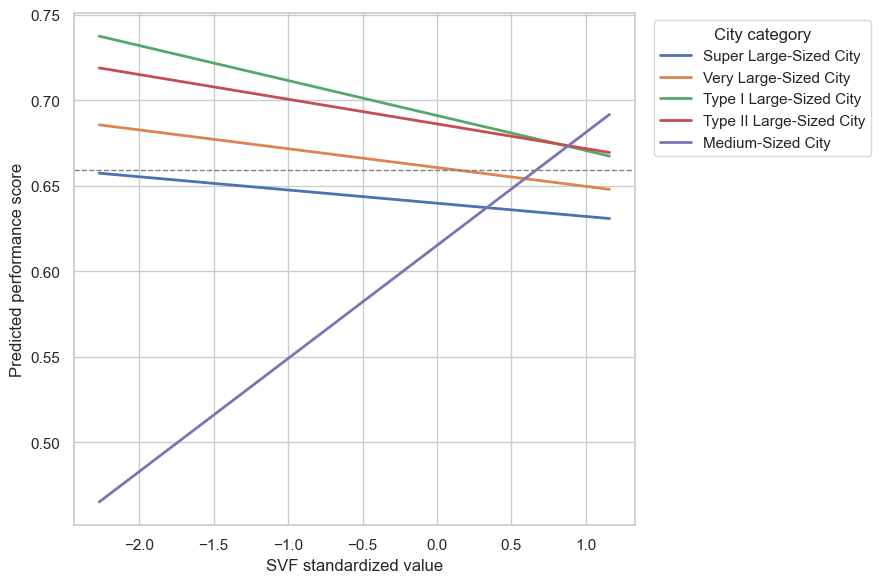

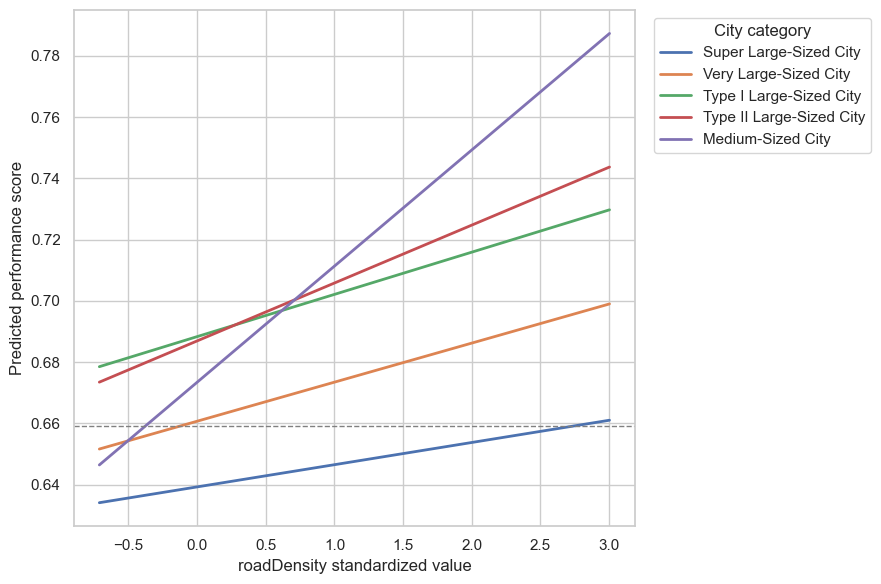

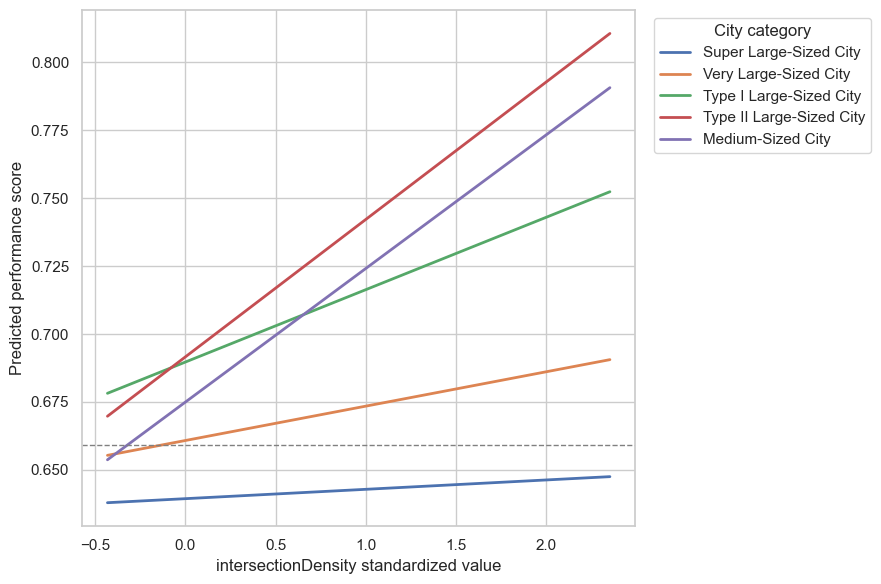

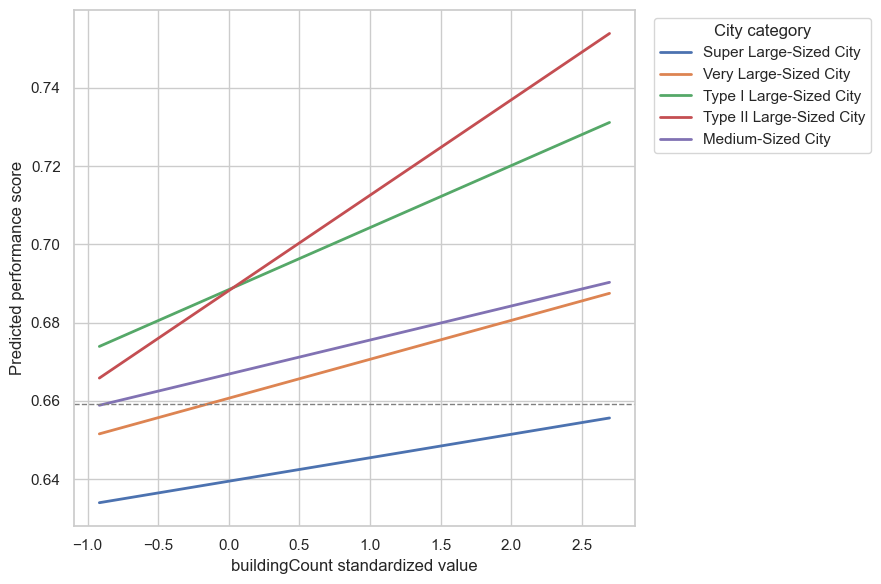

,feature,AIC,BIC,R2,adj_R2
0,SVF,-333334.8220,-332968.3257,0.4376,0.4375
1,roadDensity,-333090.9767,-332724.4804,0.4369,0.4368
2,intersectionDensity,-334092.0473,-333725.5511,0.4398,0.4397
3,buildingCount,-333273.7074,-332907.2111,0.4374,0.4373


In [11]:
RUN_CATEGORY_INTERACTION_PLOTS = True
MAX_INTERACTION_FEATURES = 4

planning_priority = [
    'FAR', 'coverageRatio', 'SVF', 'roadDensity', 'intersectionDensity',
    'buildingCount', 'avgHeight', 'FVC', 'permeableRatio', 'compactness'
]

selected_feature_names = [term.replace('_z', '') for term in z_terms]
significant_z_terms = main_coef.loc[
    (main_coef['p_value'] < 0.05) & (main_coef['term'].isin(z_terms)),
    'term'
].tolist()

interaction_features = [
    f for f in planning_priority
    if f in selected_feature_names and f'{f}_z' in significant_z_terms
]

# If no planning-priority variable is significant, plot surviving planning variables as exploratory checks.
if len(interaction_features) == 0:
    interaction_features = [f for f in planning_priority if f in selected_feature_names]

interaction_features = interaction_features[:MAX_INTERACTION_FEATURES]
print('Category interaction plotting features:', interaction_features)

interaction_summaries = []

if RUN_CATEGORY_INTERACTION_PLOTS and len(interaction_features) > 0:
    for feature in interaction_features:
        term = f'{feature}_z'
        interaction_formula = formula + f' + C(City_Category) + {term}:C(City_Category)'

        interaction_result = smf.ols(interaction_formula, data=df_ml).fit(cov_type='HC3')

        coef_table = pd.DataFrame({
            'term': interaction_result.params.index,
            'coef': interaction_result.params.values,
            'std_err': interaction_result.bse.values,
            't_value': interaction_result.tvalues.values,
            'p_value': interaction_result.pvalues.values,
        })
        coef_table.to_csv(f'{OUT_DIR}/interaction_coefficients_{feature}.csv', index=False)

        interaction_summaries.append({
            'feature': feature,
            'AIC': interaction_result.aic,
            'BIC': interaction_result.bic,
            'R2': interaction_result.rsquared,
            'adj_R2': interaction_result.rsquared_adj
        })

        x_min = df_ml[term].quantile(0.02)
        x_max = df_ml[term].quantile(0.98)
        x_grid = np.linspace(x_min, x_max, 80)

        pred_rows = []
        for category in category_order:
            if category not in df_ml['City_Category'].dropna().unique():
                continue

            pred_df = pd.DataFrame({z: 0.0 for z in z_terms}, index=range(len(x_grid)))
            pred_df[term] = x_grid
            pred_df['City_Category'] = pd.Categorical(
                [category] * len(x_grid),
                categories=category_order,
                ordered=True
            )
            pred_df['predicted_performance'] = interaction_result.predict(pred_df)
            pred_df['feature_z'] = x_grid
            pred_df['City_Category_label'] = category
            pred_rows.append(pred_df[['feature_z', 'City_Category_label', 'predicted_performance']])

        pred_plot = pd.concat(pred_rows, ignore_index=True)
        pred_plot.to_csv(f'{OUT_DIR}/interaction_predictions_{feature}.csv', index=False)

        plt.figure(figsize=(9, 6))
        sns.lineplot(
            data=pred_plot,
            x='feature_z',
            y='predicted_performance',
            hue='City_Category_label',
            linewidth=2
        )
        plt.axhline(df_ml[target].mean(), color='gray', linestyle='--', linewidth=1)
        plt.xlabel(f'{feature} standardized value')
        plt.ylabel('Predicted performance score')
        plt.legend(title='City category', bbox_to_anchor=(1.02, 1), loc='upper left')
        plt.tight_layout()
        plt.savefig(f'{OUT_DIR}/category_interaction_{feature}.png', dpi=300, bbox_inches='tight')
        plt.show()

    interaction_summary_table = pd.DataFrame(interaction_summaries)
    interaction_summary_table.to_csv(f'{OUT_DIR}/interaction_model_summary.csv', index=False)
    display(interaction_summary_table)
else:
    print('Category interaction plots skipped because no selected planning variables survived screening.')

## 11. Diagnostics

Prediction type used for diagnostics: fixed_only_singular_random_effects


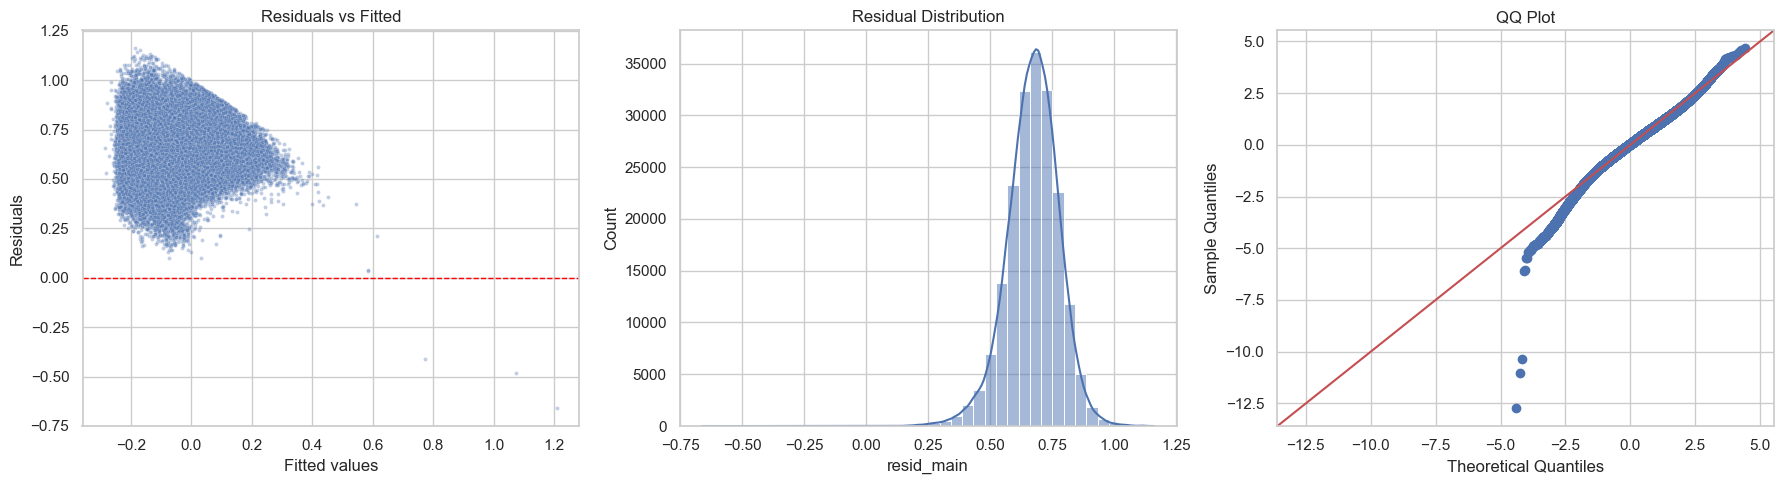

In [12]:
fitted_main, resid_main, prediction_type = safe_mixedlm_predictions(
    main_result,
    y=df_ml[target].values
)

df_ml['fitted_main'] = fitted_main
df_ml['resid_main'] = resid_main

print('Prediction type used for diagnostics:', prediction_type)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(data=df_ml, x='fitted_main', y='resid_main', s=8, alpha=0.35, ax=axes[0])
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_title('Residuals vs Fitted')
axes[0].set_xlabel('Fitted values')
axes[0].set_ylabel('Residuals')

sns.histplot(df_ml['resid_main'], bins=40, kde=True, ax=axes[1])
axes[1].set_title('Residual Distribution')

sm.qqplot(df_ml['resid_main'], line='45', fit=True, ax=axes[2])
axes[2].set_title('QQ Plot')

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/residual_diagnostics.png', dpi=300, bbox_inches='tight')
plt.show()

In [13]:
category_residuals = (
    df_ml.groupby(group_col)
    .agg(
        n=(target, 'size'),
        observed_mean=(target, 'mean'),
        fitted_mean=('fitted_main', 'mean'),
        residual_mean=('resid_main', 'mean'),
        residual_sd=('resid_main', 'std')
    )
)

category_residuals.to_csv(f'{OUT_DIR}/category_level_residuals.csv')
display(category_residuals)

,n,observed_mean,fitted_mean,residual_mean,residual_sd
City_Category,,,,,
Super Large-Sized City,71818,0.6557,0.0032,0.6525,0.0937
Very Large-Sized City,73559,0.6543,-0.0201,0.6744,0.1074
Type I Large-Sized City,38366,0.6750,-0.0269,0.7019,0.1073
Type II Large-Sized City,10173,0.6656,-0.0337,0.6994,0.1140
Medium-Sized City,1025,0.6228,-0.0590,0.6818,0.1231


## Interpretation Notes

- If the random-intercept variance is near zero, `City_Category` does not explain additional residual clustering after the selected predictors.
- If the mixed model is singular, prefer the OLS model with `C(City_Category)` fixed effects for interpretation.
- Because there are only five city-size categories, do not rely heavily on random-effect variance estimates from this notebook.
- Use the interaction plots to inspect whether common planning variables have visibly different slopes across city-size categories.